In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import os
from autoemulate import AutoEmulate
from autoemulate.core.plotting import create_and_plot_slice
# from lipb_surrogate_new import FestimProblem
import sys

In [2]:
from autoemulate.simulations.base import Simulator

N_A = 6.0221e23 # atms/mol

class FestimProblem(Simulator):
    def _forward(self):
        pass

simulator = FestimProblem(
    parameters_range={
        "v_in": (0.01, 3.5),
        "c_in": (np.log10(1e15/N_A), np.log10(1e25/N_A)),
    },  # ranges for each variable
    output_names=["c_out"],
)

In [6]:
# load training data 
# TODO: make paths generic

X = np.loadtxt("/home/kaelyn/Fusion-TES-Modeling/lipb_festim_results/with_meshes/inputs.csv", delimiter=",")
Y = np.loadtxt("/home/kaelyn/Fusion-TES-Modeling/lipb_festim_results/with_meshes/outputs.csv", delimiter=",")

# log data 
X[:,1] = np.log10(X[:,1]) 
Y = np.log10(Y)

In [7]:
# train model 
from autoemulate.emulators import GaussianProcessRBF

def make_gp(x_train, y_train, lr=5e-2):
    return GaussianProcessRBF(
        x_train, 
        y_train, 
        lr=lr, 
        standardize_y=False,
    )

# train initial emulator 
print("training initial emulator...")
emulator = make_gp(X,Y, 0.1)
emulator.fit(X,Y)

training initial emulator...


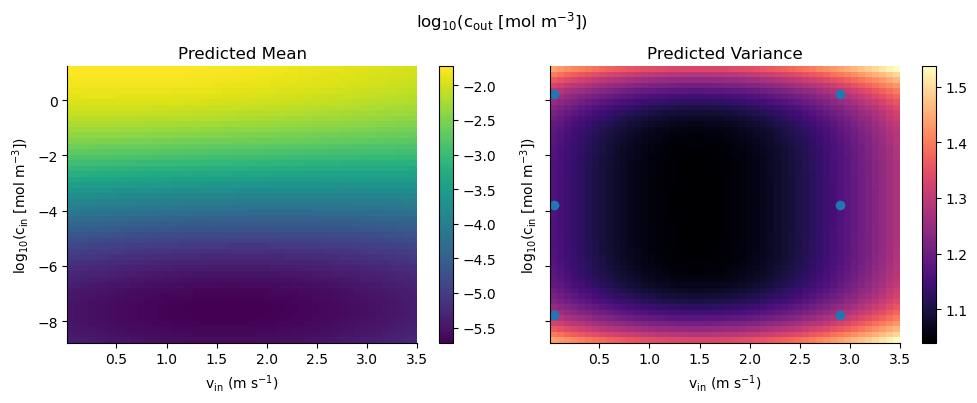

In [14]:
# plot mean and variance
for i in range(1):
    fig, axs = create_and_plot_slice(
        emulator,
        output_idx=i,
        parameters_range=simulator.parameters_range, 
        quantile=0.5,
        param_pair=(0, 1),
    )
    axs[0][0].set_xlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)")
    axs[0][1].set_xlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)")
    axs[0][0].set_ylabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])")
    axs[0][1].set_ylabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])")
    axs[0][0].set_title("Predicted Mean")
    axs[0][1].set_title("Predicted Variance")
    axs[0][0].spines["top"].set_visible(False)
    axs[0][1].spines["top"].set_visible(False)
    axs[0][0].spines["right"].set_visible(False)
    axs[0][1].spines["right"].set_visible(False)

    plt.scatter(X[:, 0], X[:, 1])
    plt.suptitle(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
    plt.savefig("mean-variance.pdf")
    plt.show()
    


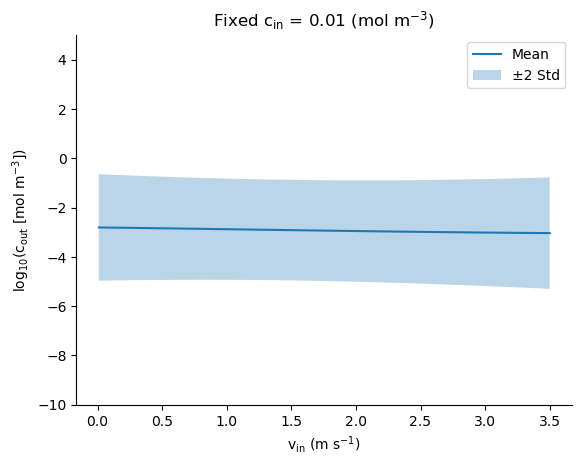

In [19]:
# plot 1d slice fixed c_in
import torch

n_points = 50
v_in_range = simulator.parameters_range["v_in"]
fixed_c_in = -2 # in log scale, chosen from plot above 

v_in_vals = np.linspace(v_in_range[0], v_in_range[1], n_points)
v_in = np.column_stack([
    v_in_vals,
    np.full(n_points, fixed_c_in),
])
v_in = torch.from_numpy(v_in).float()

y_mean, y_var = emulator.predict_mean_and_variance(v_in)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values 
y_mean_1d = y_mean[:, 0]  
y_std_1d = np.sqrt(y_var) 

# actual plotting 
ax.plot(v_in_vals, y_mean_1d, label='Mean')
ax.fill_between(v_in_vals,
                y_mean_1d - 2*y_std_1d,
                y_mean_1d + 2*y_std_1d,
                alpha=0.3, label='±2 Std')
ax.set_xlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)")
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed c$_{\mathrm{in}}$ = 0.01 (mol m$^{-3}$)")
ax.set_ylim(-10, 5)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.savefig("cin-fixed.pdf")
plt.show()


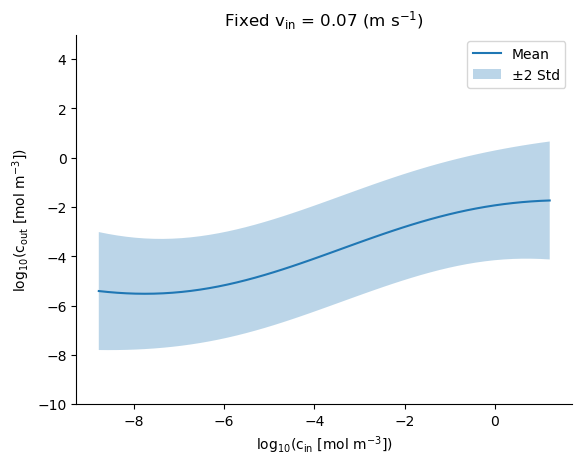

In [26]:
# plot 1d slice for fixed v_in

n_points = 50
c_in_range = simulator.parameters_range["c_in"]
fixed_v_in = 0.07

c_in_vals = np.linspace(c_in_range[0], c_in_range[1], n_points)
c_in = np.column_stack([
    np.full(n_points, fixed_v_in),
    c_in_vals,
])
c_in = torch.from_numpy(c_in).float()


y_mean, y_var = emulator.predict_mean_and_variance(c_in)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values 
y_mean_1d = y_mean[:, 0]  
y_std_1d = np.sqrt(y_var) 

# actual plotting 
ax.plot(c_in_vals, y_mean_1d, label='Mean')
ax.fill_between(c_in_vals,
                y_mean_1d - 2*y_std_1d,
                y_mean_1d + 2*y_std_1d,
                alpha=0.3, label='±2 Std')
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_xlabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed v$_{\mathrm{in}}$ = 0.07 (m s$^{-1}$)")
ax.set_ylim(-10, 5)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig("vin-fixed.pdf")
ax.legend()
plt.show()